# Result 3 — unchecked realm diagnostics

**Nothing in this notebook is cited by the manuscript.** It holds the parts of the
realm analysis that support no reported sentence, so that
`03_realm_composition.ipynb` stays exactly manuscript-complete.

| Section | Why it is not in the manuscript |
| --- | --- |
| L1 driver composition across all 10 realms | The paper's figure shows the three core realms only; its caption states transition realms are omitted |
| L1 composition with mapped Threat-L0 detail | The nested view resolves each L1 block into proximate threats; no sentence reports it |
| Threat-L0 relative research emphasis (LQ heatmap) | Result 3 makes its argument in IPBES driver space, not Threat-L0 space |
| Threat-L0 fractional composition, all and core realms | Same — no Threat-L0 realm value is reported |

The threat-side material is kept because it is fully built and documented, not because it
is pending publication — treat it as parked. Counting is unchanged from the manuscript
notebook: one publication is the unit, each contributing total weight one divided equally
across the labels it carries.

This notebook rebuilds the realm frame from the same prepared corpus rather than importing
it, because the threat-side sections need the publication-level realm evidence that the
manuscript notebook neither builds nor exports.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis.realm import driver as driver_realm
from data_helpers.analysis.realm import driver_plotting as driver_realm_plotting
from data_helpers.analysis.realm import threat as threat_realm
from data_helpers.analysis.realm import threat_plotting as threat_realm_plotting
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
REALM_CONFIG = RESULTS_CONFIG["driver_realm"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
DRIVER_CATALOG, DRIVER_COLORS, DRIVER_NAMES = results_config.driver_l1_display(
    RESULTS_CONFIG
)
DRIVER_ORDER = tuple(results_config.driver_l1_stack_order(RESULTS_CONFIG))

REALM_ORDER = tuple(REALM_CONFIG["analysis_realms"])
CORE_REALMS = tuple(REALM_CONFIG["core_realms"])
REALM_NAMES = REALM_CONFIG["realm_display_names"]
REALM_SHORT_NAMES = REALM_CONFIG["realm_short_names"]
START_YEAR = REALM_CONFIG["primary_start_year"]
END_YEAR = REALM_CONFIG["primary_end_year"]
CORE_REALM_COLORS = {
    "Terrestrial": "#E69F00",
    "Freshwater": "#009E73",
    "Marine": "#0072B2",
}
PLASTICS_PATTERN = driver_realm.DEFAULT_PLASTICS_PATTERN

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

THREAT_REALM_CONFIG = RESULTS_CONFIG["threat_realm"]
THREAT_CATALOG, THREAT_COLORS, THREAT_NAMES = results_config.threat_l0_display(
    RESULTS_CONFIG
)
THREAT_STACK_ORDER = results_config.threat_l0_stack_order(RESULTS_CONFIG)
THREAT_ORDER = [
    threat
    for threat in THREAT_CATALOG
    if threat not in THREAT_REALM_CONFIG["out_of_scope_threats"]
]
FIGURE_THREATS = tuple(
    threat
    for threat in THREAT_STACK_ORDER
    if threat in THREAT_REALM_CONFIG["figure_threats"]
)
DRIVER_TO_THREAT_L0 = {
    "Land/sea use change": (
        "Residential & Commercial Development",
        "Agriculture & Aquaculture",
        "Energy Production & Mining",
        "Transportation & Service Corridors",
        "Natural System Modifications",
    ),
    "Direct Exploitation and Resource Extraction": (
        "Biological Resource Use",
    ),
    "Climate Change": ("Climate Change & Severe Weather",),
    "Pollution": ("Pollution",),
    "Invasive alien species": (
        "Invasive & Other Problematic Species, Genes & Diseases",
    ),
}

OUTPUT_DIR = PROJECT_ROOT / REALM_CONFIG["unchecked_output_directory"]
TABLE_DIR = OUTPUT_DIR / REALM_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / REALM_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Writing: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


def save_table(table, filename, index=False):
    path = TABLE_DIR / f"{filename}.csv"
    table.to_csv(path, index=index)
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
    return path


def save_figure(figure, filename):
    return visualization.save_figure(
        figure, FIGURE_DIR / filename, formats=["pdf"], dpi=300, pad_inches=0.05
    )

Writing: notebooks/results/outputs/03_unchecked_realm_composition


## 1. Rebuild the shared realm frame

Same filters, window and realm vocabulary as the manuscript notebook, plus the Threat-L0
evidence the threat-side sections below need.

In [5]:
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR).load(
    columns=["UT", "publication_year", "s2_dir", "driver", "realm", "pred_threat_l0"]
).publications
prepared = driver_realm.prepare_realm_evidence(
    corpus_df,
    analysis_realms=REALM_ORDER,
    direction=REALM_CONFIG["direction"],
    start_year=START_YEAR,
    end_year=END_YEAR,
)
realm_counts = driver_realm.realm_counts(prepared.evidence)
realm_supports = realm_counts.set_index("realm")["n_documents"].to_dict()
driver_summary = driver_realm.driver_realm_summary(prepared.evidence)

core_driver_summary = driver_summary.loc[
    driver_summary["realm"].isin(CORE_REALMS)
].copy()
threat_evidence = threat_realm.prepare_threat_realm_evidence(
    prepared,
    corpus_df,
    threat_order=THREAT_ORDER,
    threat_column=THREAT_REALM_CONFIG["label_column"],
)
threat_summary = threat_realm.threat_realm_summary(threat_evidence)
threat_composition = threat_realm.threat_realm_fractional_composition(
    threat_evidence,
    threat_order=FIGURE_THREATS,
)

display(realm_counts)
display(threat_evidence.audit)

,realm,n_documents,share_of_analysis_documents
0,Terrestrial,114710,0.493625
1,Subterranean,1047,0.004505
2,Subterranean-Freshwater,1117,0.004807
3,Subterranean-Marine,36,0.000155
4,Freshwater-Terrestrial,2567,0.011046
5,Freshwater,64684,0.278351
6,Freshwater-Marine,8492,0.036543
7,Marine,36136,0.155502
8,Marine-Terrestrial,3195,0.013749
9,Marine-Freshwater-Terrestrial,399,0.001717


,metric,value
0,Primary analysis publications,232383
1,Publications matched to threat corpus,232383
2,Publications absent from threat corpus,0
3,Publications with an empty threat prediction,0
4,Publications carrying an unknown threat label,0
5,Publications carrying an out-of-scope threat l...,0
6,Publications without a usable canonical threat,0
7,Threat-labelled publications,232383
8,Multi-threat publications,51353
9,Unique document–threat assignments,301220


## 2. L1 driver fractional composition across all 10 realms

Each publication contributes total weight one, divided equally across all IPBES L1 drivers
assigned to it. All 10 exact-singleton ecological realm labels are retained as distinct
categories, including the transition and subterranean ones the manuscript figure omits.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_unchecked_realm_composition/figures/l1_driver_composition_all_realms.pdf


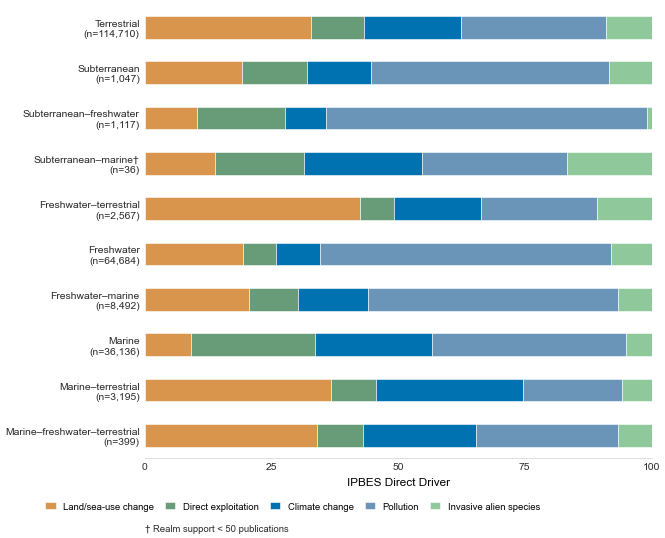

In [6]:
all_realm_driver_bar_figure = driver_realm_plotting.plot_driver_fractional_bars(
    driver_summary,
    driver_order=DRIVER_ORDER,
    realm_order=REALM_ORDER,
    driver_names=DRIVER_NAMES,
    realm_names=REALM_NAMES,
    realm_supports=realm_supports,
    driver_colors=DRIVER_COLORS,
    figure_height=5.4,
)
save_figure(
    all_realm_driver_bar_figure, REALM_CONFIG["l1_all_realm_bar_figure_filename"]
)
plt.show()

## 3. L1 composition with available mapped Threat-L0 detail

The thick bars retain the three-core-realm L1 fractional composition. Each thin strip
resolves its parent L1 block using only available, directly mapped substantive Threat-L0
labels. Missing predictions, `Unclear`, `Other Options`, Geological Events, and Threat-L0
labels unrelated to that L1 driver are excluded from the conditional denominator.
Publications with multiple related threats contribute total weight one divided equally
across those threats. The Land/sea-use annotation reports the usable mapped sample and its
coverage of publications carrying that L1 driver.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_unchecked_realm_composition/figures/l1_driver_with_threat_l0_detail_core_realms.pdf


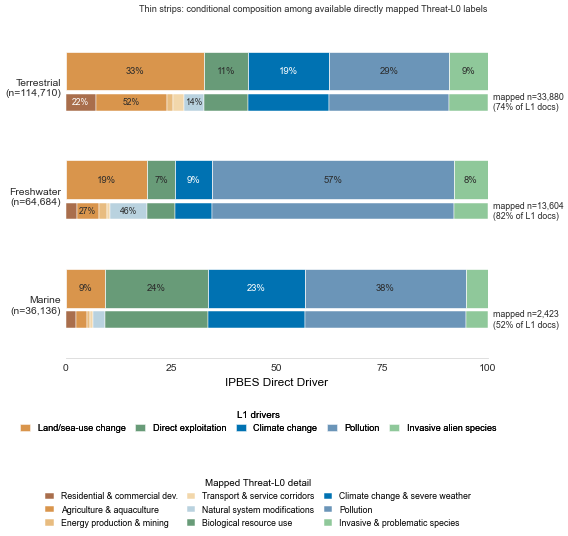

In [7]:
core_driver_threat_detail = threat_realm.conditional_driver_threat_composition(
    prepared.evidence,
    threat_evidence,
    driver_to_threats=DRIVER_TO_THREAT_L0,
    realm_order=CORE_REALMS,
)
core_nested_figure = driver_realm_plotting.plot_driver_threat_nested_bars(
    core_driver_summary,
    core_driver_threat_detail,
    driver_order=DRIVER_ORDER,
    realm_order=CORE_REALMS,
    driver_names=DRIVER_NAMES,
    realm_names=REALM_NAMES,
    realm_supports=realm_supports,
    driver_colors=DRIVER_COLORS,
    driver_to_threats=DRIVER_TO_THREAT_L0,
    threat_names=THREAT_NAMES,
    threat_colors=THREAT_COLORS,
    detail_driver="Land/sea use change",
    figure_height=5.4,
)
save_figure(core_nested_figure, REALM_CONFIG["l1_core_nested_figure_filename"])
plt.show()

## 4. Threat-L0 relative research emphasis

Heatmap color represents within-realm Threat-L0 prevalence relative to the pooled 10-realm
evidence base. Rows follow the family-grouped Threat-L0 order, and the narrow strip beside
each label uses its configured Threat-L0 color. `Other Options` and `Unclear` are omitted
from this map, and `Geological Events` is outside the map's coding scope.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_unchecked_realm_composition/figures/threat_l0_lq_by_realm.pdf


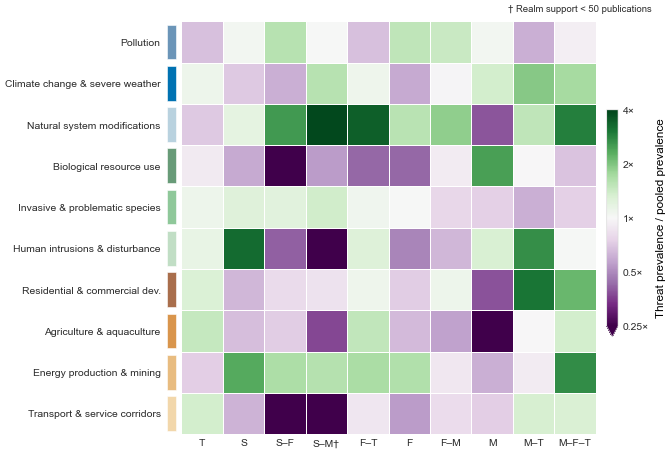

In [8]:
threat_figure_estimates = threat_summary.loc[
    threat_summary["threat"].isin(FIGURE_THREATS)
].copy()
threat_lq_figure = threat_realm_plotting.plot_threat_realm_heatmap(
    threat_figure_estimates,
    threat_order=FIGURE_THREATS,
    realm_order=REALM_ORDER,
    realm_supports=realm_supports,
    threat_colors=THREAT_COLORS,
    threat_names=THREAT_NAMES,
    realm_names=REALM_SHORT_NAMES,
    lq_limit=THREAT_REALM_CONFIG["lq_plot_cap"],
)
save_figure(threat_lq_figure, THREAT_REALM_CONFIG["figure_filename"])
plt.show()

## 5. Threat-L0 fractional composition

Each publication carrying at least one of the 10 substantive Threat-L0 classes contributes
total weight one, divided equally across its substantive threats. `Other Options` and
`Unclear` do not appear as segments, and publications carrying only those residual labels
do not enter the composition denominator. All 10 realms first, then the three core realms
as an explicit subset with percentages printed inside segments at least 6 points wide.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_unchecked_realm_composition/figures/threat_l0_composition_all_realms.pdf


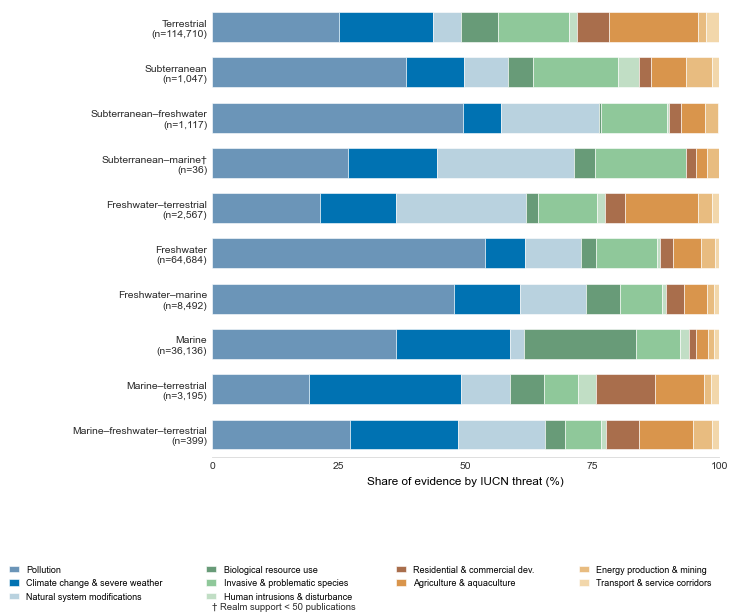

In [9]:
all_realm_threat_bar_figure = threat_realm_plotting.plot_threat_fractional_bars(
    threat_composition,
    threat_order=FIGURE_THREATS,
    realm_order=REALM_ORDER,
    realm_supports=realm_supports,
    threat_colors=THREAT_COLORS,
    threat_names=THREAT_NAMES,
    realm_names=REALM_NAMES,
    figure_height=6.2,
)
save_figure(
    all_realm_threat_bar_figure, THREAT_REALM_CONFIG["all_realm_bar_figure_filename"]
)
plt.show()

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_unchecked_realm_composition/figures/threat_l0_composition_core_realms.pdf


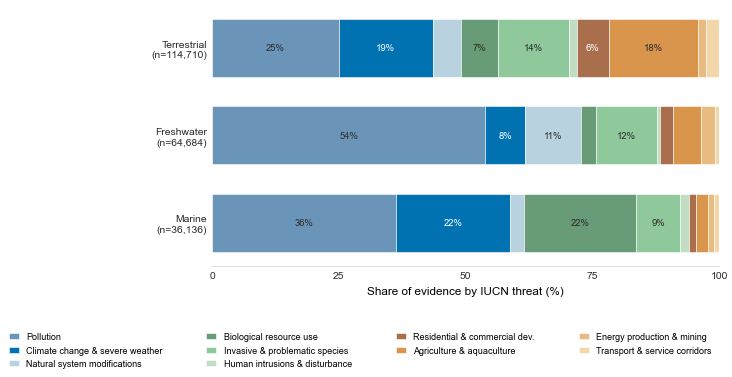

In [10]:
core_threat_composition = threat_composition.loc[
    threat_composition["realm"].isin(CORE_REALMS)
].copy()
core_threat_bar_figure = threat_realm_plotting.plot_threat_fractional_bars(
    core_threat_composition,
    threat_order=FIGURE_THREATS,
    realm_order=CORE_REALMS,
    realm_supports=realm_supports,
    threat_colors=THREAT_COLORS,
    threat_names=THREAT_NAMES,
    realm_names=REALM_NAMES,
    figure_height=3.8,
    show_segment_labels=True,
    segment_label_min_pct=6.0,
)
save_figure(
    core_threat_bar_figure, THREAT_REALM_CONFIG["core_realm_bar_figure_filename"]
)
plt.show()

## 6. Export the intermediate tables

The threat-side summaries and the conditional driver→threat detail. None is a reported
value; all are useful when checking the figures above by hand.

In [11]:
for table, filename in (
    (threat_summary, "threat_realm_summary"),
    (threat_composition, "threat_realm_composition"),
    (threat_evidence.audit, "threat_realm_audit"),
    (core_driver_threat_detail, "core_realm_driver_threat_detail"),
):
    save_table(table, filename)
for path in sorted(FIGURE_DIR.glob("*.pdf")):
    print(path.relative_to(PROJECT_ROOT))

Saved: notebooks/results/outputs/03_unchecked_realm_composition/csv/threat_realm_summary.csv
Saved: notebooks/results/outputs/03_unchecked_realm_composition/csv/threat_realm_composition.csv
Saved: notebooks/results/outputs/03_unchecked_realm_composition/csv/threat_realm_audit.csv
Saved: notebooks/results/outputs/03_unchecked_realm_composition/csv/core_realm_driver_threat_detail.csv
notebooks/results/outputs/03_unchecked_realm_composition/figures/l1_driver_composition_all_realms.pdf
notebooks/results/outputs/03_unchecked_realm_composition/figures/l1_driver_with_threat_l0_detail_core_realms.pdf
notebooks/results/outputs/03_unchecked_realm_composition/figures/threat_l0_composition_all_realms.pdf
notebooks/results/outputs/03_unchecked_realm_composition/figures/threat_l0_composition_core_realms.pdf
notebooks/results/outputs/03_unchecked_realm_composition/figures/threat_l0_lq_by_realm.pdf
